### import packages

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from stAggregator import stAggregator
from stAggregator import metrics
from stAggregator.data import process_adata, process_graph
from stAggregator.data import process_graph

In [4]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [5]:
def refine_label(adata, radius=50, key='label'):
    import ot
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values
    
    #calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')
           
    n_cell = distance.shape[0]
    
    for i in range(n_cell):
        vec  = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh+1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)
        
    new_type = [str(i) for i in list(new_type)]    
    #adata.obs['label_refined'] = np.array(new_type)
    
    return new_type

In [6]:
def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=42):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    adata.obsm['mclust_prob'] = np.array(res[-3])
    return adata

In [7]:
def mclust_R_smooth(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=42):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    adata.obsm['mclust_prob'] = np.array(res[-3])

    adata.obs['mclust'] = refine_label(adata, 50, key='mclust')
    
    return adata

In [8]:
def clear_fig(fig):
    if fig:
        fig.axes[0].set_xlabel(None)
        fig.axes[0].set_ylabel(None)
        fig.tight_layout()
    else:
        pass
    return fig

In [20]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # 

### load data

In [11]:
adata1 = sc.read_h5ad(f'./data/Mouse_olfa_S1.h5ad')
adata1.obs_names_make_unique()
adata1.var_names_make_unique()

adata2 = sc.read_h5ad(f'./data/Slide-seqV2_MoB.h5ad')
adata2.obs_names_make_unique()
adata2.var_names_make_unique()
data_list = [adata1, adata2]
batch_key = 'batch'
batch_names = ['adata1', 'adata2']
adata = process_adata(data_list, batch_key=batch_key, batch_categories=batch_names, n_top_features=3000)
rad_cutoff_list = [3, 50]
adata = process_graph(adata, data_list, rad_cutoff_list=rad_cutoff_list)

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:87: ImplicitModificationWarning: Setting element `.obsm['feature_scale']` of view, initializing view as actual.
  adata.obsm['feature_scale'] = adata_scale.X


------Calculating spatial graph...


E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spatial_Net['Cell1'] = Spatial_Net['Cell1'].map(id_cell_trans)
E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spatial_Net['Cell2'] = Spatial_Net['Cell2'].map(id_cell_trans)


The graph contains 2511116 edges, 107416 cells.
23.3775 neighbors per cell on average.
------Calculating spatial graph...


E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spatial_Net['Cell1'] = Spatial_Net['Cell1'].map(id_cell_trans)
E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spatial_Net['Cell2'] = Spatial_Net['Cell2'].map(id_cell_trans)


The graph contains 228288 edges, 20139 cells.
11.3356 neighbors per cell on average.


### train

In [12]:
path_results = f'./log/integration1/'
adata_stAggregator = stAggregator(adata=adata, max_iteration=2000, outdir=path_results, h_dim=16,
                       batch_size=1024, impute=False, early_stop=False, random_seed=42)

Epochs:   0%|                                                                                                                                                  | 0/16 [00:00<?, ?it/s]C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\dgl\dataloading\dataloader.py:859: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(f'Dataloader CPU affinity opt is not enabled, consider switching it on '
Epochs: 100%|████████████████████████████████████████████████████████████████| 16/16 [03:53<00:00, 14.59s/it, recon_loss_mse=99443.015, sl1_loss=160.482, sl2_loss=164.466, lr: 0.001]
2025-09-28 12:18:00,982 - root - INFO - Output dir: ./log/integration1/


In [13]:
adata_stAggregator

AnnData object with n_obs × n_vars = 127555 × 3000
    obs: 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'feature_scale', 'X_stAggregator', 'X_emb'
    layers: 'counts'

In [14]:
adata_stAggregator = sc.read_h5ad('./log/integration1/adata_stAggregator.h5ad')
adata_stAggregator

AnnData object with n_obs × n_vars = 127555 × 3000
    obs: 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    obsm: 'X_emb', 'X_stAggregator', 'feature_scale', 'spatial'
    layers: 'counts'

In [15]:
sc.pp.neighbors(adata_stAggregator, use_rep='X_stAggregator')

In [16]:
sc.tl.umap(adata_stAggregator)

In [17]:
sc.tl.louvain(adata_stAggregator, resolution=0.7)

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\User

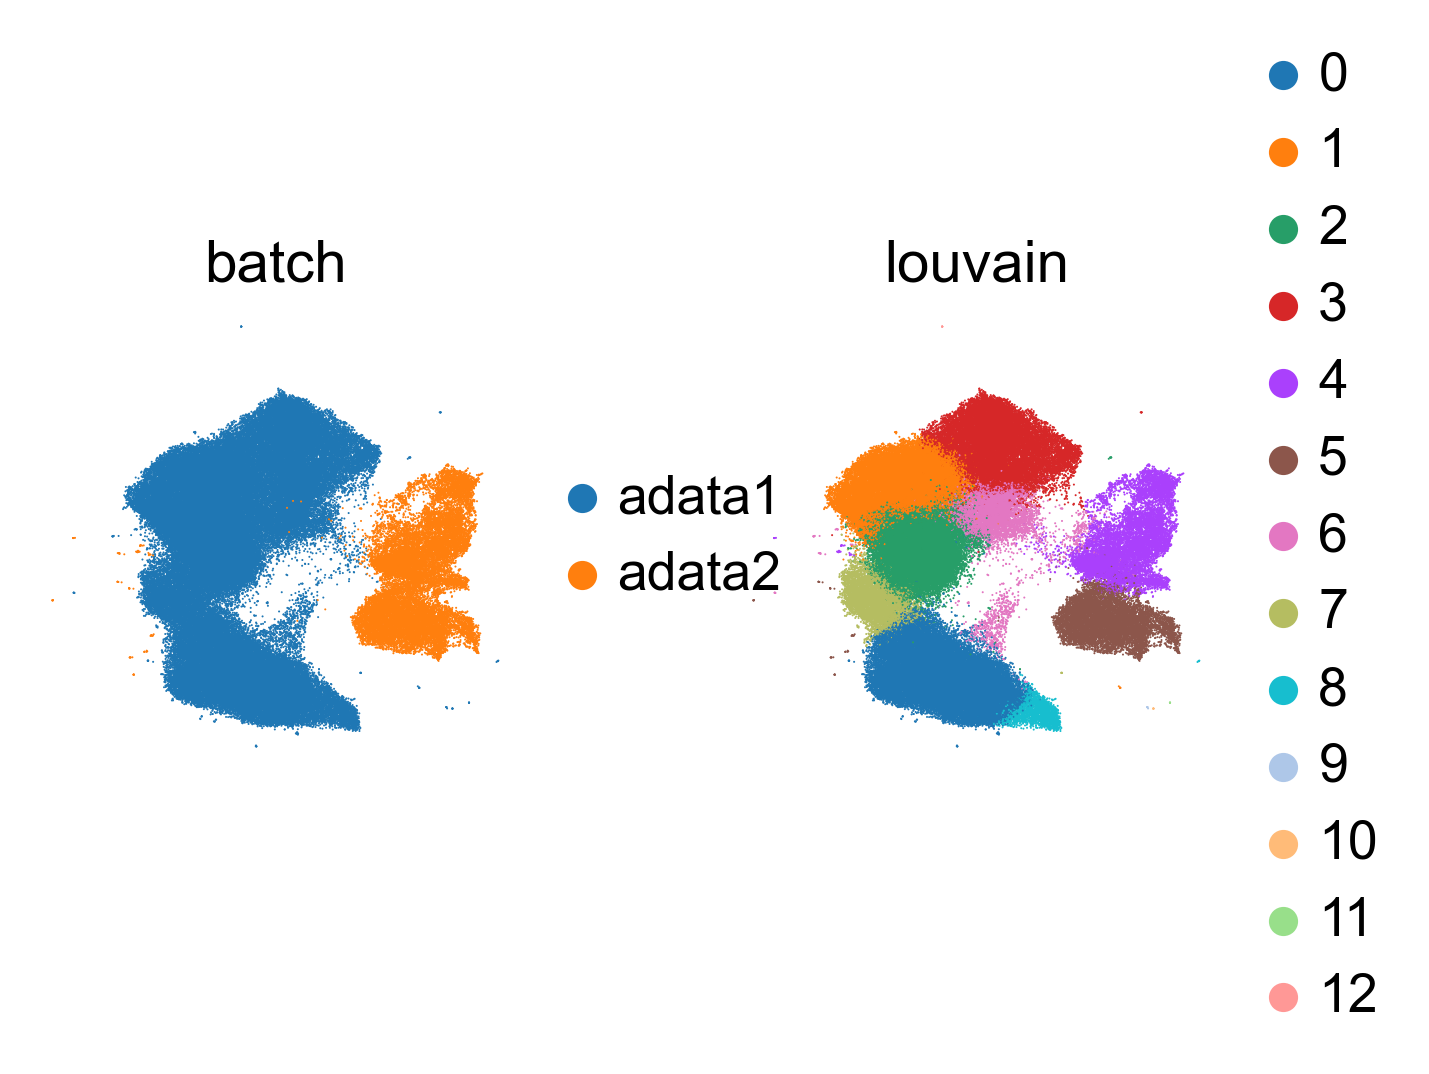

In [22]:
sc.pl.umap(adata_stAggregator, color=['batch', 'louvain'], wspace=0.3)

In [23]:
import scanpy.external as sce

In [24]:
sce.pp.harmony_integrate(adata_stAggregator, 'batch', basis='X_stAggregator')

2025-09-28 12:25:04,132 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-28 12:25:04,132 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-28 12:25:12,267 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-28 12:25:12,267 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-28 12:25:12,788 - harmonypy - INFO - Iteration 1 of 10
2025-09-28 12:25:12,788 - harmonypy - INFO - Iteration 1 of 10
2025-09-28 12:26:02,105 - harmonypy - INFO - Iteration 2 of 10
2025-09-28 12:26:02,105 - harmonypy - INFO - Iteration 2 of 10
2025-09-28 12:26:34,254 - harmonypy - INFO - Converged after 2 iterations
2025-09-28 12:26:34,254 - harmonypy - INFO - Converged after 2 iterations


In [25]:
adata_stAggregator.obsm['X_pca_harmony'].shape

(127555, 16)

In [26]:
sc.pp.neighbors(adata_stAggregator, use_rep='X_pca_harmony')

In [27]:
sc.tl.umap(adata_stAggregator)

In [28]:
sc.tl.louvain(adata_stAggregator, resolution=1)

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\User

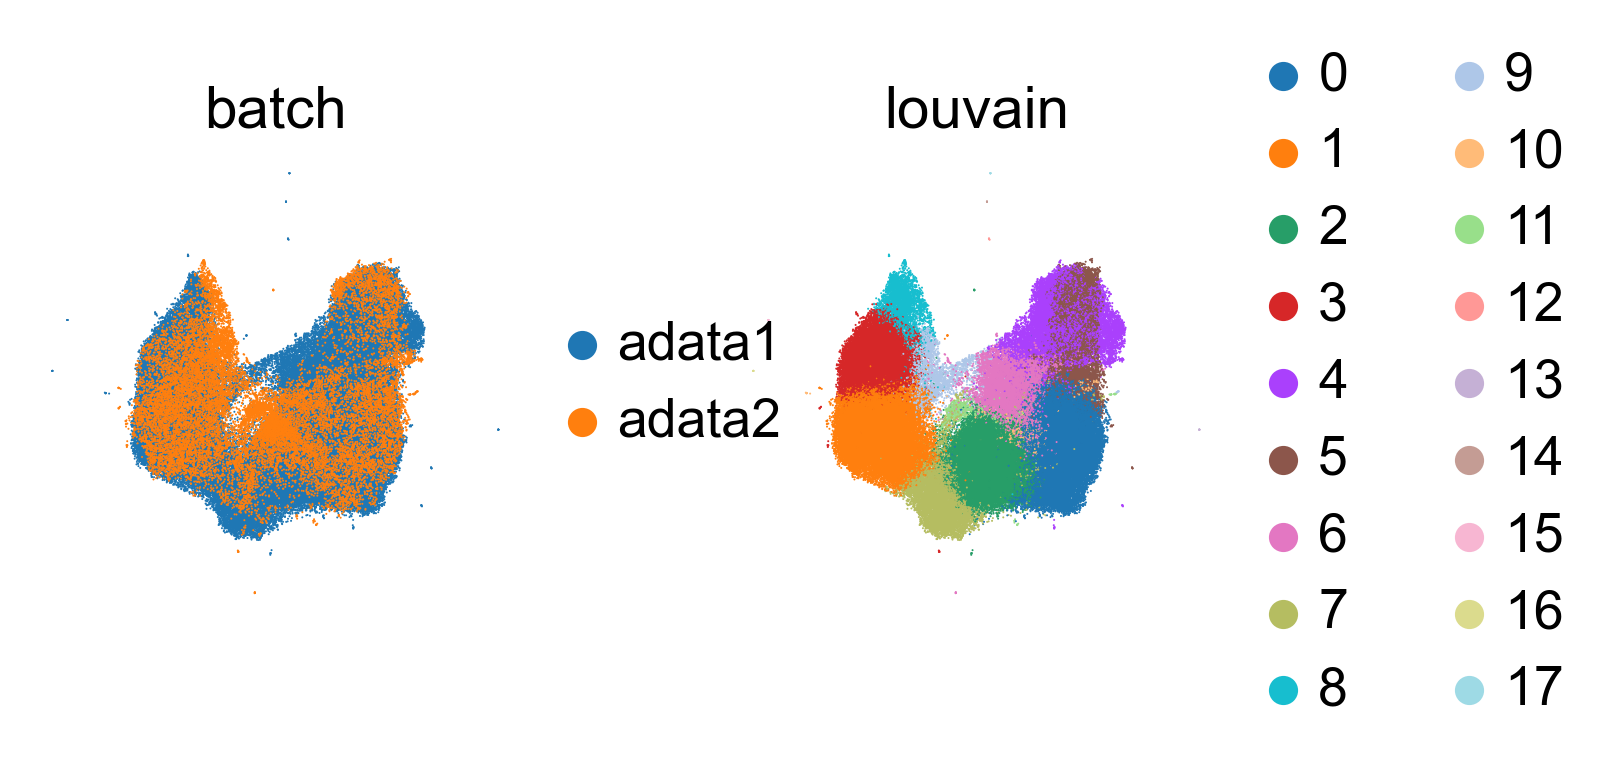

In [29]:
sc.pl.umap(adata_stAggregator, color=['batch', 'louvain'], wspace=0.3)

In [30]:
adata_stAggregator1 = adata_stAggregator[adata_stAggregator.obs['batch'] == 'adata1', :]
adata_stAggregator1

View of AnnData object with n_obs × n_vars = 107416 × 3000
    obs: 'batch', 'louvain', 'leiden'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'neighbors', 'umap', 'louvain', 'leiden', 'batch_colors', 'louvain_colors', 'leiden_colors'
    obsm: 'X_emb', 'X_stAggregator', 'feature_scale', 'spatial', 'X_umap', 'X_pca_harmony'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\User

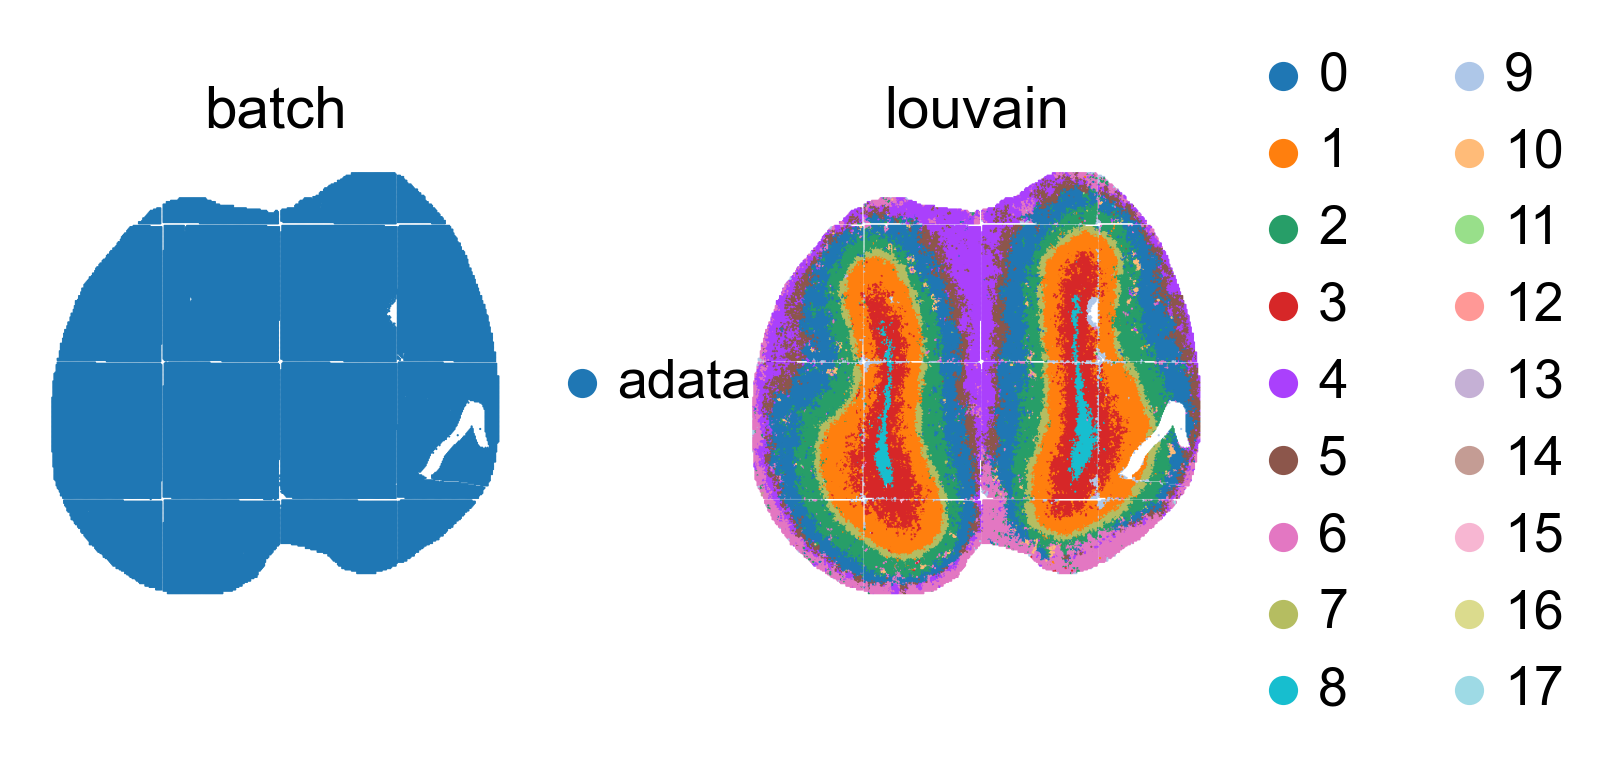

In [31]:
sc.pl.embedding(adata_stAggregator1, color=['batch', 'louvain'], wspace=0.3, basis='spatial')

In [32]:
adata_stAggregator2 = adata_stAggregator[adata_stAggregator.obs['batch'] == 'adata2', :]
adata_stAggregator2

View of AnnData object with n_obs × n_vars = 20139 × 3000
    obs: 'batch', 'louvain', 'leiden'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'neighbors', 'umap', 'louvain', 'leiden', 'batch_colors', 'louvain_colors', 'leiden_colors'
    obsm: 'X_emb', 'X_stAggregator', 'feature_scale', 'spatial', 'X_umap', 'X_pca_harmony'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\User

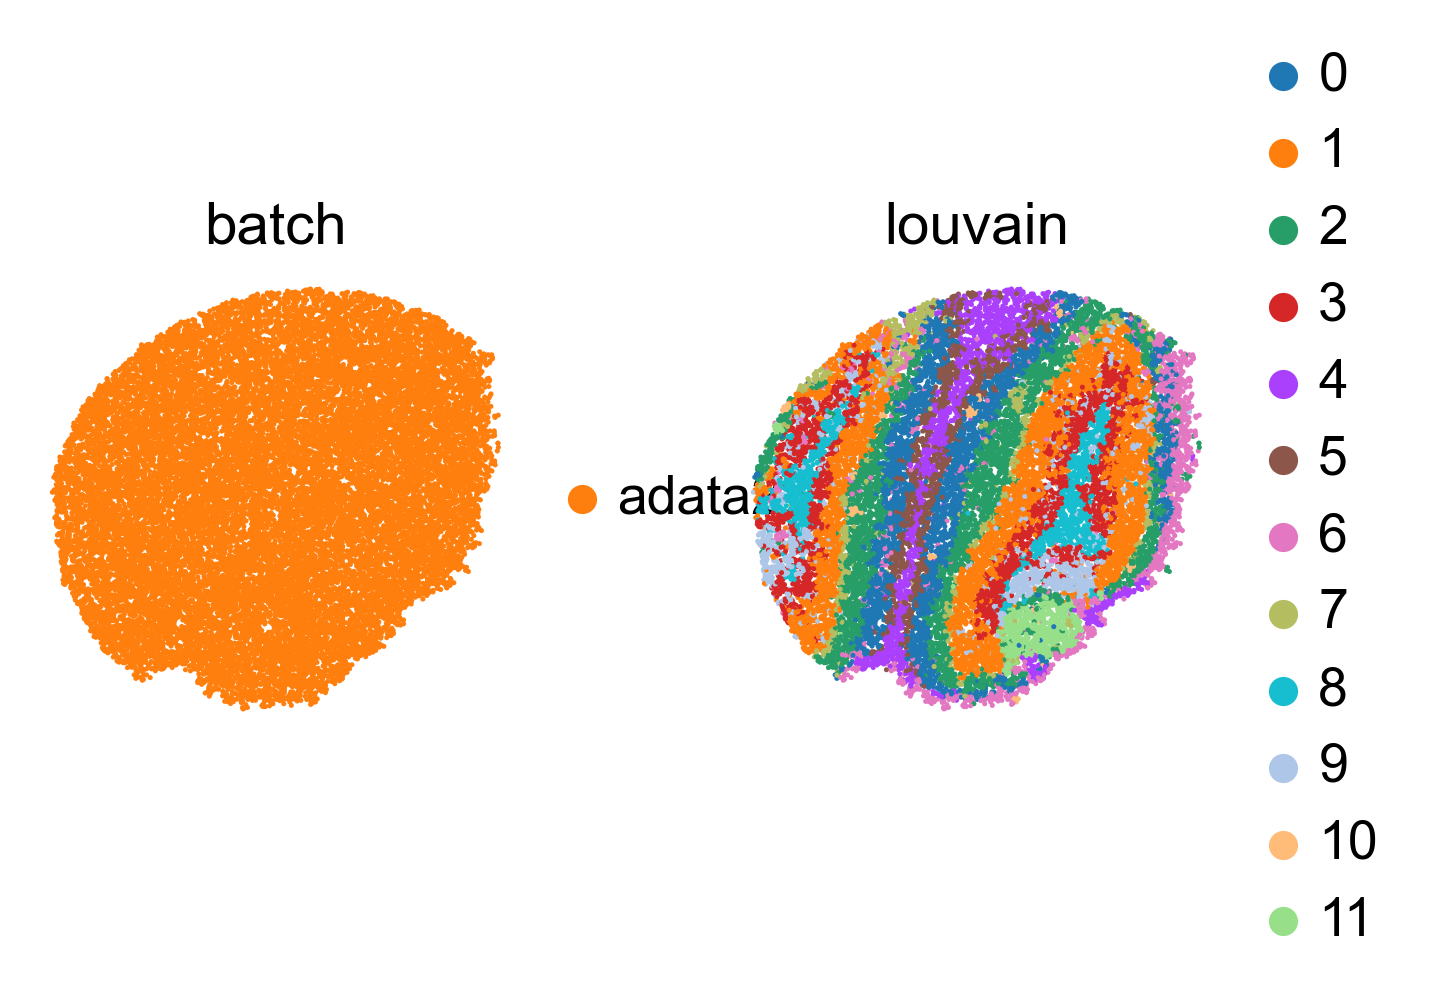

In [33]:
sc.pl.embedding(adata_stAggregator2, color=['batch', 'louvain'], wspace=0.3, basis='spatial')